# Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score

SEED = 42

# Load data

In [5]:
stat_df_clahe = pd.read_csv("../data/ml_features/features_stat_clahe.csv")
lbp_df_clahe = pd.read_csv("../data/ml_features/features_lbp_clahe.csv")
hog_df_clahe = pd.read_csv("../data/ml_features/features_hog_clahe.csv")
stat_df_no_clahe = pd.read_csv("../data/ml_features/features_stat_no_clahe.csv")
lbp_df_no_clahe = pd.read_csv("../data/ml_features/features_lbp_no_clahe.csv")
hog_df_no_clahe = pd.read_csv("../data/ml_features/features_hog_no_clahe.csv")

# Feature combinations

In [7]:
id_cols = ["image_name", "class"]

df_stat_clahe = stat_df_clahe.copy()
df_lbp_clahe = lbp_df_clahe.copy()
df_hog_clahe = hog_df_clahe.copy()
df_stat_lbp_clahe = df_stat_clahe.merge(df_lbp_clahe, on=id_cols)
df_stat_hog_clahe = df_stat_clahe.merge(df_hog_clahe, on=id_cols)
df_lbp_hog_clahe = df_lbp_clahe.merge(df_hog_clahe, on=id_cols)
df_stat_lbp_hog_clahe = (df_stat_clahe.merge(df_lbp_clahe, on=id_cols).merge(df_hog_clahe, on=id_cols))

df_stat_no_clahe = stat_df_no_clahe.copy()
df_lbp_no_clahe = lbp_df_no_clahe.copy()
df_hog_no_clahe = hog_df_no_clahe.copy()
df_stat_lbp_no_clahe = df_stat_no_clahe.merge(df_lbp_no_clahe, on=id_cols)
df_stat_hog_no_clahe = df_stat_no_clahe.merge(df_hog_no_clahe, on=id_cols)
df_lbp_hog_no_clahe = df_lbp_no_clahe.merge(df_hog_no_clahe, on=id_cols)
df_stat_lbp_hog_no_clahe = (df_stat_no_clahe.merge(df_lbp_no_clahe, on=id_cols).merge(df_hog_no_clahe, on=id_cols))

datasets = {
    "STAT_CLAHE": df_stat_clahe,
    "LBP_CLAHE": df_lbp_clahe,
    "HOG_CLAHE": df_hog_clahe,
    "STAT_LBP_CLAHE": df_stat_lbp_clahe,
    "STAT_HOG_CLAHE": df_stat_hog_clahe,
    "LBP_HOG_CLAHE": df_lbp_hog_clahe,
    "STAT_LBP_HOG_CLAHE": df_stat_lbp_hog_clahe,
    "STAT_NO_CLAHE": df_stat_no_clahe,
    "LBP_NO_CLAHE": df_lbp_no_clahe,
    "HOG_NO_CLAHE": df_hog_no_clahe,
    "STAT_LBP_NO_CLAHE": df_stat_lbp_no_clahe,
    "STAT_HOG_NO_CLAHE": df_stat_hog_no_clahe,
    "LBP_HOG_NO_CLAHE": df_lbp_hog_no_clahe,
    "STAT_LBP_HOG_NO_CLAHE": df_stat_lbp_hog_no_clahe,
}


# Training

### Functions

In [8]:
def prepare_dataset(df):
    df = df.copy()

    X = df.drop(columns=["image_name", "class"])
    y = df["class"]

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.2,
        random_state=SEED,
        stratify=y_encoded
    )

    return X_train, X_test, y_train, y_test, label_encoder

In [9]:
def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    return model

### Training

In [12]:
datasets_test = {
    "STAT_CLAHE": df_stat_clahe,
    "LBP_CLAHE": df_lbp_clahe,
}

results = []
trained_models = {}

for name, df in datasets.items():

    print("=" * 80)
    print(name)
    print("=" * 80)

    X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df)

    model = train_random_forest(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "dataset": name,
        "n_features": X_train.shape[1],
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    })

    trained_models[name] = {
        "model": model,
        "label_encoder": label_encoder,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred
    }

    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

df_results = pd.DataFrame(results)

display(
    df_results.sort_values("f1_macro", ascending=False)
)

STAT_CLAHE
                 precision    recall  f1-score   support

          COVID       0.63      0.66      0.64       723
   Lung_Opacity       0.77      0.74      0.75      1203
         Normal       0.84      0.83      0.83      2038
Viral Pneumonia       0.62      0.70      0.66       269

       accuracy                           0.77      4233
      macro avg       0.71      0.73      0.72      4233
   weighted avg       0.77      0.77      0.77      4233

LBP_CLAHE
                 precision    recall  f1-score   support

          COVID       0.58      0.53      0.55       723
   Lung_Opacity       0.67      0.66      0.67      1203
         Normal       0.78      0.78      0.78      2038
Viral Pneumonia       0.60      0.78      0.68       269

       accuracy                           0.70      4233
      macro avg       0.66      0.69      0.67      4233
   weighted avg       0.70      0.70      0.70      4233

HOG_CLAHE
                 precision    recall  f1-score   su

,dataset,n_features,accuracy,f1_macro,f1_weighted
6,STAT_LBP_HOG_CLAHE,617,0.820695,0.813829,0.820377
13,STAT_LBP_HOG_NO_CLAHE,617,0.812190,0.807386,0.812388
4,STAT_HOG_CLAHE,591,0.810773,0.801570,0.809832
3,STAT_LBP_CLAHE,41,0.808646,0.790607,0.808450
11,STAT_HOG_NO_CLAHE,591,0.796126,0.789064,0.796315
10,STAT_LBP_NO_CLAHE,41,0.799669,0.787031,0.800016
12,LBP_HOG_NO_CLAHE,602,0.785967,0.777134,0.785700
5,LBP_HOG_CLAHE,602,0.784314,0.771952,0.782884
9,HOG_NO_CLAHE,576,0.763525,0.749001,0.761453
2,HOG_CLAHE,576,0.763525,0.744376,0.760972


# Results

### Functions

In [13]:
def plot_confusion_matrix(model_name, normalize=None):
    data = trained_models[model_name]

    cm = confusion_matrix(
        data["y_test"],
        data["y_pred"],
        normalize=normalize
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=data["label_encoder"].classes_
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        values_format=".2f" if normalize else "d"
    )

    title = f"Confusion Matrix - {model_name}"
    if normalize:
        title = f"Normalized Confusion Matrix - {model_name}"

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [14]:
def plot_learning_curve_for_dataset(dataset_name):

    df = datasets_clahe[dataset_name]

    X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df)

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="f1_macro",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))

    plt.plot(train_sizes, train_mean, marker="o", label="Train")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation")

    plt.title(f"Learning Curve - {dataset_name}")
    plt.xlabel("Training examples")
    plt.ylabel("F1 macro")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [15]:
def plot_feature_importance(model_name, top_n=30):

    data = trained_models[model_name]
    model = data["model"]
    X_train = data["X_train"]

    importances = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    })

    importances = importances.sort_values(
        "importance",
        ascending=False
    ).head(top_n)

    plt.figure(figsize=(8, 8))
    plt.barh(
        importances["feature"][::-1],
        importances["importance"][::-1]
    )

    plt.title(f"Top {top_n} Feature Importances - {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

### Performance visualisation

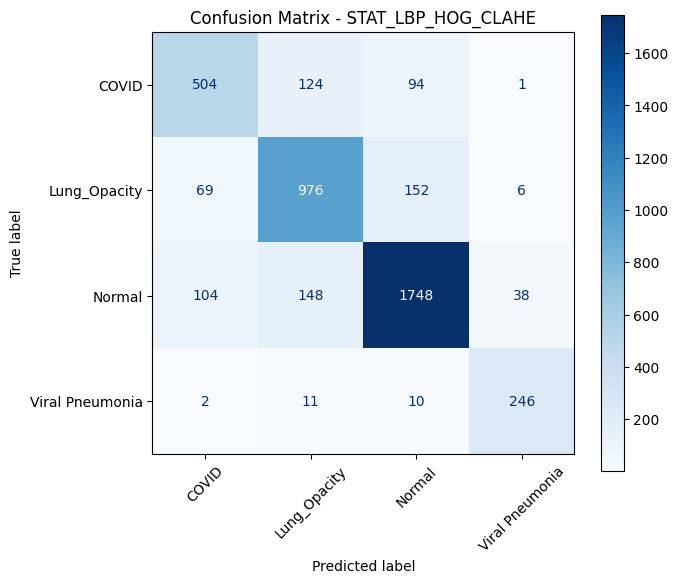

In [16]:
plot_confusion_matrix("STAT_LBP_HOG_CLAHE")

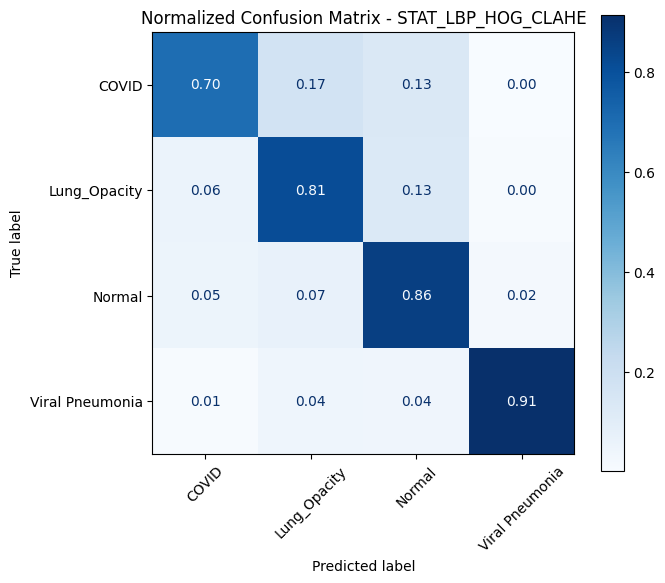

In [17]:
plot_confusion_matrix("STAT_LBP_HOG_CLAHE", normalize="true")

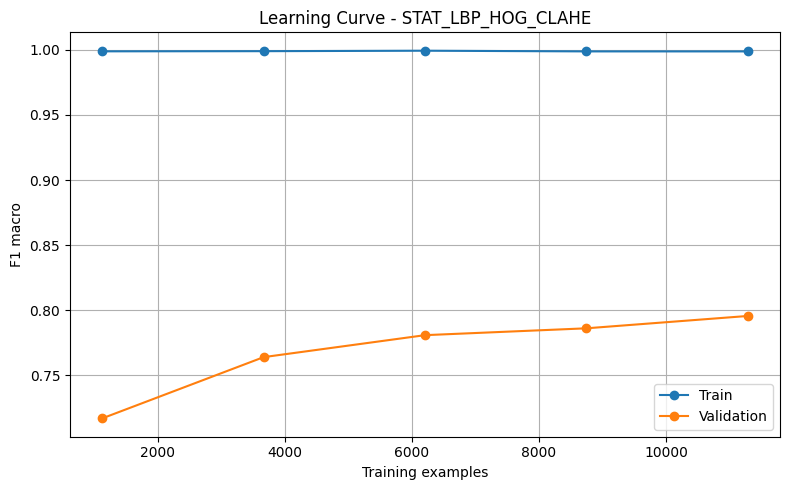

In [18]:
plot_learning_curve_for_dataset("STAT_LBP_HOG_CLAHE")

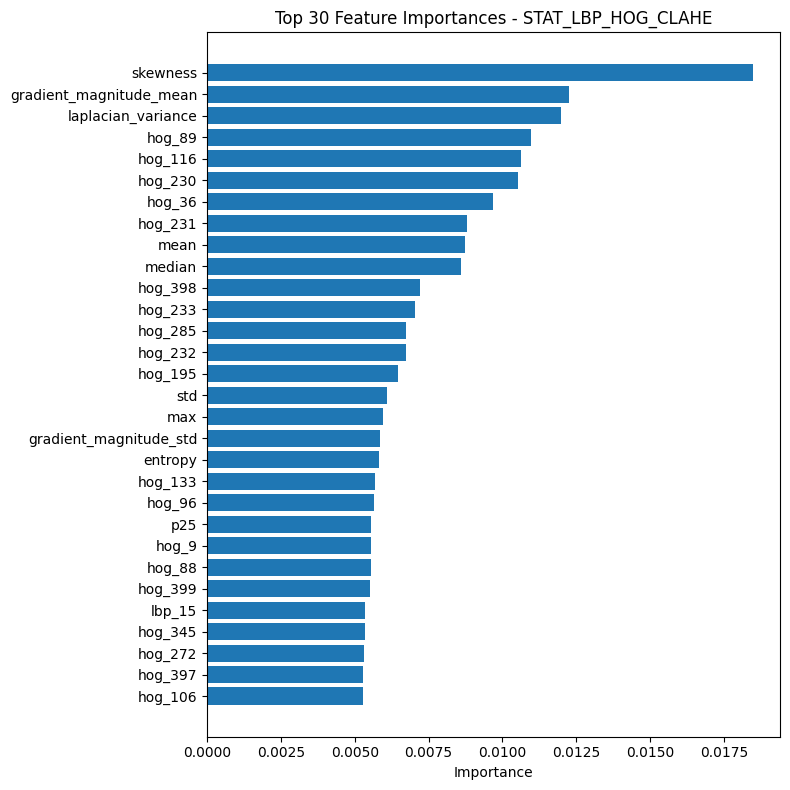

In [19]:
plot_feature_importance("STAT_LBP_HOG_CLAHE")